Configuration Display

loading files: ising_Size512_T2.269_Batch500_1.npy
config index: 79, size: 512x512
Extracting interface...


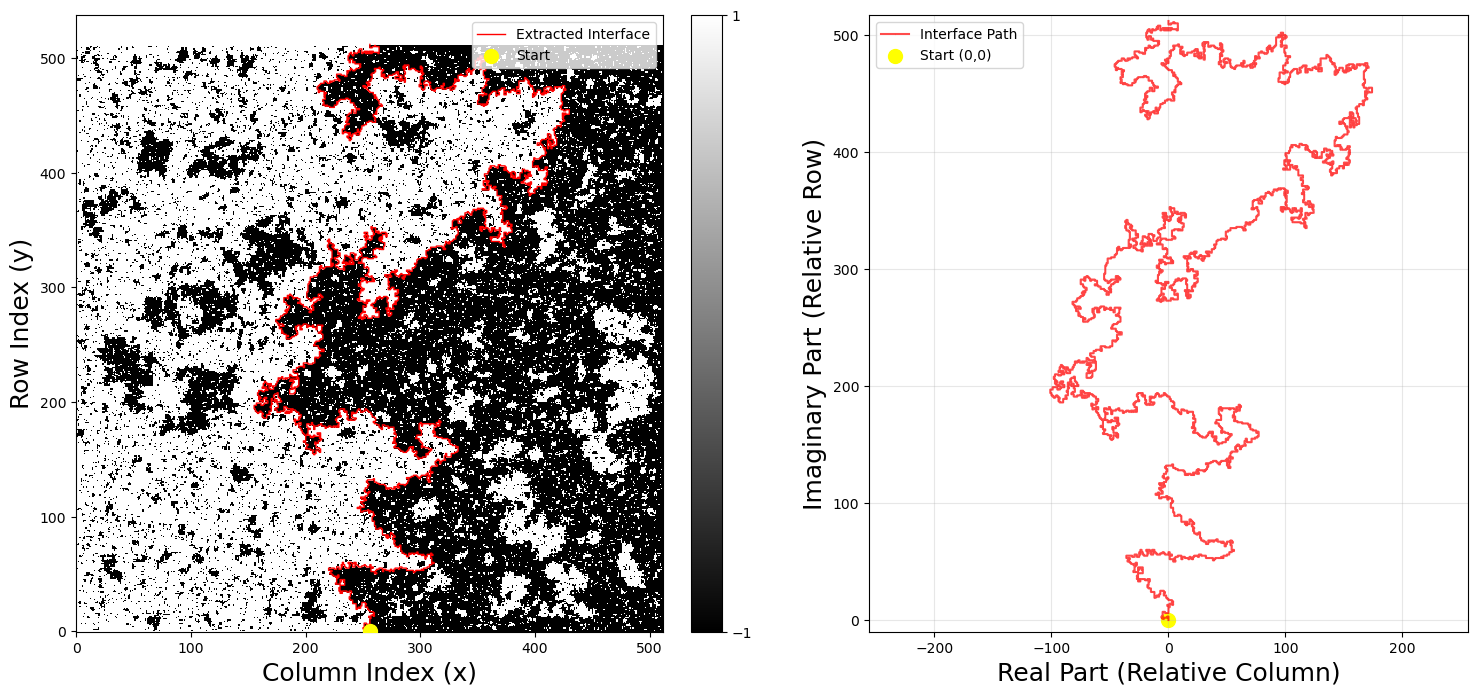

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import os


@njit
def get_interface_path_fast(grid):
    rows, cols = grid.shape
    max_len = rows * cols 
    path_r = np.zeros(max_len, dtype=np.int32)
    path_c = np.zeros(max_len, dtype=np.int32)
    
    start_col = cols // 2
    curr_r = 0
    curr_c = start_col
    direction = 0 # 0:上, 1:右, 2:下, 3:左
    
    idx = 0
    path_r[idx] = curr_r
    path_c[idx] = curr_c
    idx += 1
    
    while curr_r < rows and idx < max_len:
       
        if direction == 0:   curr_r += 1
        elif direction == 1: curr_c += 1
        elif direction == 2: curr_r -= 1
        elif direction == 3: curr_c -= 1
        
        path_r[idx] = curr_r
        path_c[idx] = curr_c
        idx += 1
        
        if curr_r == rows: break
            
       
        tl = grid[curr_r, curr_c - 1] if (curr_c - 1 >= 0 and curr_r < rows) else 1
        tr = grid[curr_r, curr_c]     if (curr_c < cols and curr_r < rows) else -1
        bl = grid[curr_r - 1, curr_c - 1] if (curr_r - 1 >= 0 and curr_c - 1 >= 0) else 1
        br = grid[curr_r - 1, curr_c]     if (curr_r - 1 >= 0 and curr_c < cols) else -1
        
        
        if idx > 1 and curr_r == path_r[idx-2] and curr_c == path_c[idx-2]:
            break

        
        can_go_north = (tl == 1 and tr == -1)
        can_go_east  = (tr == 1 and br == -1)
        can_go_south = (br == 1 and bl == -1)
        can_go_west  = (tl == -1 and bl == 1)
        
        if direction == 0: 
            if can_go_east: direction = 1
            elif can_go_north: direction = 0
            elif can_go_west: direction = 3
            else: direction = 2
        elif direction == 1: 
            if can_go_south: direction = 2
            elif can_go_east: direction = 1
            elif can_go_north: direction = 0
            else: direction = 3
        elif direction == 2: 
            if can_go_west: direction = 3
            elif can_go_south: direction = 2
            elif can_go_east: direction = 1
            else: direction = 0
        elif direction == 3: 
            if can_go_north: direction = 0
            elif can_go_west: direction = 3
            elif can_go_south: direction = 2
            else: direction = 1
            
    return path_r[:idx], path_c[:idx]


def visualize_single_config():
    file_path = r"D:\Code\final_srgan\configurations\512x512\ising_Size512_T2.269_Batch500_1.npy"
    config_index = 79 

    if not os.path.exists(file_path):
        print(f"file doesn't exist: {file_path}")
        return


    print(f"loading files: {os.path.basename(file_path)}")
    batch_configs = np.load(file_path)
    

    grid = batch_configs[config_index]
    rows, cols = grid.shape
    print(f"config index: {config_index}, size: {rows}x{cols}")


    print("Extracting interface...")

    r_path_raw, c_path_raw = get_interface_path_fast(grid.astype(np.int32))

    

    r_relative = r_path_raw - r_path_raw[0]
    c_relative = c_path_raw - c_path_raw[0]
    

    x_plot = c_relative  
    y_plot = r_relative  


    fig, axes = plt.subplots(1, 2, figsize=(16, 7))


    ax1 = axes[0]

    im = ax1.imshow(grid, cmap='grey', origin='lower', interpolation='nearest')
    ax1.plot(c_path_raw, r_path_raw, color='red', linewidth=1.0, label='Extracted Interface')
    ax1.scatter(c_path_raw[0], r_path_raw[0], color='yellow', s=100, zorder=5, label='Start')
    ax1.set_xlabel("Column Index (x)",fontsize=18)
    ax1.set_ylabel("Row Index (y)",fontsize=18)
    ax1.legend(loc='upper right')
    plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, ticks=[-1, 1])



    ax2 = axes[1]
    ax2.plot(x_plot, y_plot, color='red', linewidth=1.5, marker='_', markersize=0.1, alpha=0.7, label='Interface Path')
    ax2.scatter(x_plot[0], y_plot[0], color='yellow', s=100, label='Start (0,0)')
    ax2.set_xlabel("Real Part (Relative Column)",fontsize=18)
    ax2.set_ylabel("Imaginary Part (Relative Row)",fontsize=18)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal', adjustable='box')
    max_range = max(np.max(np.abs(x_plot)), np.max(y_plot))
    ax2.set_xlim(-max_range*0.5, max_range*0.5)
    ax2.set_ylim(-10, max_range*1.01) 

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_single_config()

SLE diffusion coeffcient \kappa by drive function

[MC] loading files


Loading MC: 100%|██████████| 10000/10000 [00:04<00:00, 2094.81it/s]


[SRGAN] loading files


Loading SRGAN: 100%|██████████| 10000/10000 [00:04<00:00, 2137.11it/s]


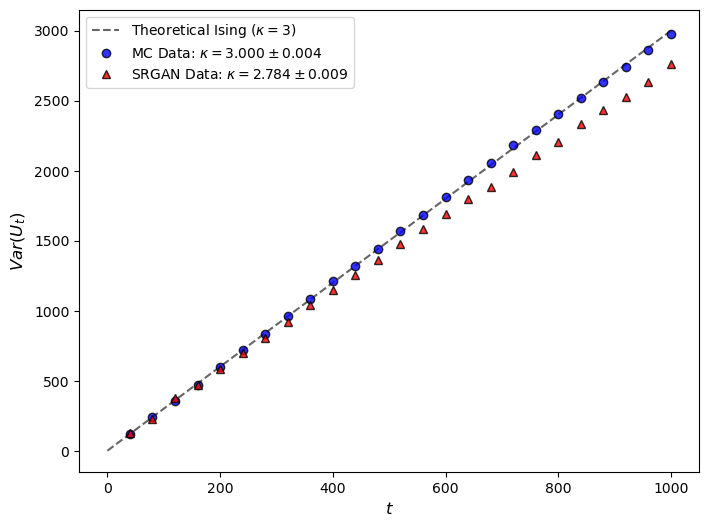

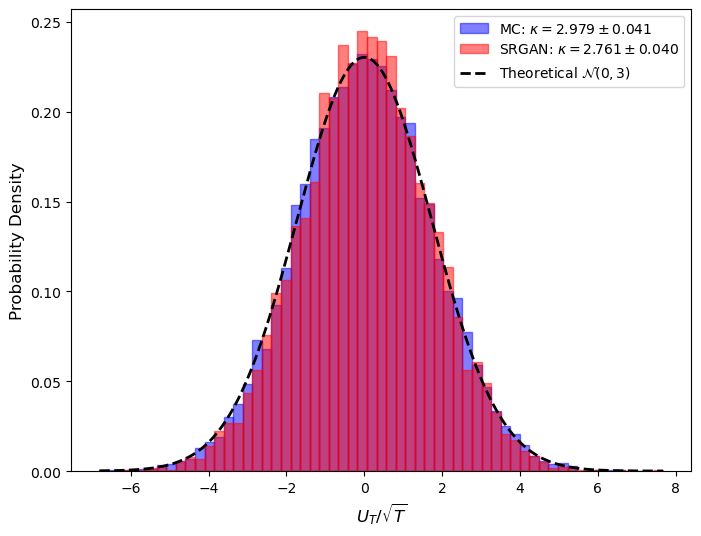

In [ ]:
import numpy as np
import h5py
import os
import matplotlib.pyplot as plt
from tqdm import tqdm


PATH_MC = r".ising_512x512_10000_driven_results.h5"
PATH_SRGAN = r".srgan_output_ising_2048x2048_10000_driven_results.h5"

OUTPUT_DIR = r"comparison_plots"  
os.makedirs(OUTPUT_DIR, exist_ok=True)

T_MAX = 1000
INTERVAL = 25   
BATCH_SIZE = 10000 
N_BOOTSTRAP = 1000 

def get_data_from_file(filepath, label_name):

    print(f"[{label_name}] loading files")
    
    if not os.path.exists(filepath):
        print(f"file doesn't exist")
        return None, None, None

    t_targets = np.linspace(T_MAX / INTERVAL, T_MAX, INTERVAL)
    Ut_interval = []
    U_at_Tmax = []
    
    with h5py.File(filepath, 'r') as hf:
        keys = sorted(hf['t'].keys(), key=lambda x: int(x.split('_')[1]))
        keys = keys[:BATCH_SIZE]
        
        for key in tqdm(keys, desc=f"Loading {label_name}"):
            t_series = hf['t'][key][:]
            u_series = hf['u'][key][:]
            
           
            if len(t_series) < 2 or t_series[-1] < T_MAX:
                continue
                   
            current_U_vals = np.zeros(INTERVAL)
            indices = np.searchsorted(t_series, t_targets, side='left')
            
            
            for i in range(INTERVAL):
                idx = indices[i]
                if idx >= len(t_series): idx = len(t_series) - 1
                if idx > 0:
                    if abs(t_targets[i] - t_series[idx-1]) < abs(t_targets[i] - t_series[idx]):
                        idx = idx - 1
                current_U_vals[i] = u_series[idx]
            Ut_interval.append(current_U_vals)
            
            idx_end = np.searchsorted(t_series, T_MAX)
            if idx_end >= len(t_series): idx_end = len(t_series) - 1
            elif idx_end > 0:
                if abs(t_series[idx_end-1] - T_MAX) < abs(t_series[idx_end] - T_MAX):
                    idx_end = idx_end - 1
            U_at_Tmax.append(u_series[idx_end])


    Ut_matrix = np.array(Ut_interval).T  
    var_U_t = np.var(Ut_matrix, axis=1) 
    
    U_vals = np.array(U_at_Tmax)
    X_final = U_vals / np.sqrt(T_MAX)   
    
    return t_targets, var_U_t, X_final

def calc_regression_through_origin(x, y):
    numerator = np.sum(x * y)
    denominator = np.sum(x ** 2)
    slope = numerator / denominator
    
    y_pred = slope * x
    residuals = y - y_pred

    dof = len(x) - 1
    mse = np.sum(residuals ** 2) / dof
    stderr = np.sqrt(mse / denominator)
    
    return slope, stderr

def bootstrap_variance_error(data, n_boot=1000):
    variances = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        variances.append(np.var(sample))
    
    return np.std(variances)

def main():

    t_mc, var_mc, X_mc = get_data_from_file(PATH_MC, "MC")
    t_sr, var_sr, X_sr = get_data_from_file(PATH_SRGAN, "SRGAN")
    
    if t_mc is None or t_sr is None:
        print("fail to load the file")
        return


    kappa_mc, err_mc_reg = calc_regression_through_origin(t_mc, var_mc)
    kappa_sr, err_sr_reg = calc_regression_through_origin(t_sr, var_sr)
    
    var_mc_hist = np.var(X_mc)
    var_sr_hist = np.var(X_sr)
    
    err_mc_boot = bootstrap_variance_error(X_mc, N_BOOTSTRAP)
    err_sr_boot = bootstrap_variance_error(X_sr, N_BOOTSTRAP)

    # linear
    plt.figure(figsize=(8, 6))
    
    t_line = np.linspace(0, T_MAX, 100)
    plt.plot(t_line, 3 * t_line, 'k--', linewidth=1.5, alpha=0.6, label='Theoretical Ising ($\kappa=3$)')
    
    # MC 
    plt.plot(t_mc, var_mc, 'o', color='blue', markeredgecolor='k', markersize=6, alpha=0.8,
             label=f'MC Data: $\kappa={kappa_mc:.3f} \pm {err_mc_reg:.3f}$')
    
    # SRGAN
    plt.plot(t_sr, var_sr, '^', color='red', markeredgecolor='k', markersize=6, alpha=0.8,
             label=f'SRGAN Data: $\kappa={kappa_sr:.3f} \pm {err_sr_reg:.3f}$')
    
    plt.xlabel('$t$', fontsize=12)
    plt.ylabel('$Var(U_t)$', fontsize=12)
    plt.legend(frameon=True, fontsize=10)
    plt.show()

    # histogram
    plt.figure(figsize=(8, 6))
    all_data = np.concatenate([X_mc, X_sr])
    bins = np.linspace(min(all_data), max(all_data), 60) 
    
    # MC
    plt.hist(X_mc, bins=bins, density=True, alpha=0.5, color='blue', edgecolor='blue', 
             label=f'MC: $\kappa={var_mc_hist:.3f} \pm {err_mc_boot:.3f}$')
    
    # SRGAN
    plt.hist(X_sr, bins=bins, density=True, alpha=0.5, color='red', edgecolor='red', 
             label=f'SRGAN: $\kappa={var_sr_hist:.3f} \pm {err_sr_boot:.3f}$')
    
   
    x_range = np.linspace(min(all_data), max(all_data), 200)
    sigma_theo = np.sqrt(3.0)
    gaussian_theo = (1 / (sigma_theo * np.sqrt(2 * np.pi))) * np.exp(-0.5 * (x_range / sigma_theo)**2)
    plt.plot(x_range, gaussian_theo, 'k--', linewidth=2, label='Theoretical $\mathcal{N}(0, 3)$')
    plt.xlabel(r'$U_T / \sqrt{T}$', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.legend(frameon=True, fontsize=10)
    plt.show()



if __name__ == "__main__":
    main()

KS test


>>> Extracting U(t=1000.0) for MC L=512 ...



>>> Extracting U(t=1000.0) for SRGAN L=512 ...



                       K-S TEST (Fixed t={int(TARGET_T)})                       
Label           | Kappa    | KS Dist (D)  | P-value   
--------------------------------------------------------------------------------
MC L=512        | 3.0130   | 0.006187     | 9.17e-01
SRGAN L=512     | 2.7702   | 0.014882     | 5.72e-02


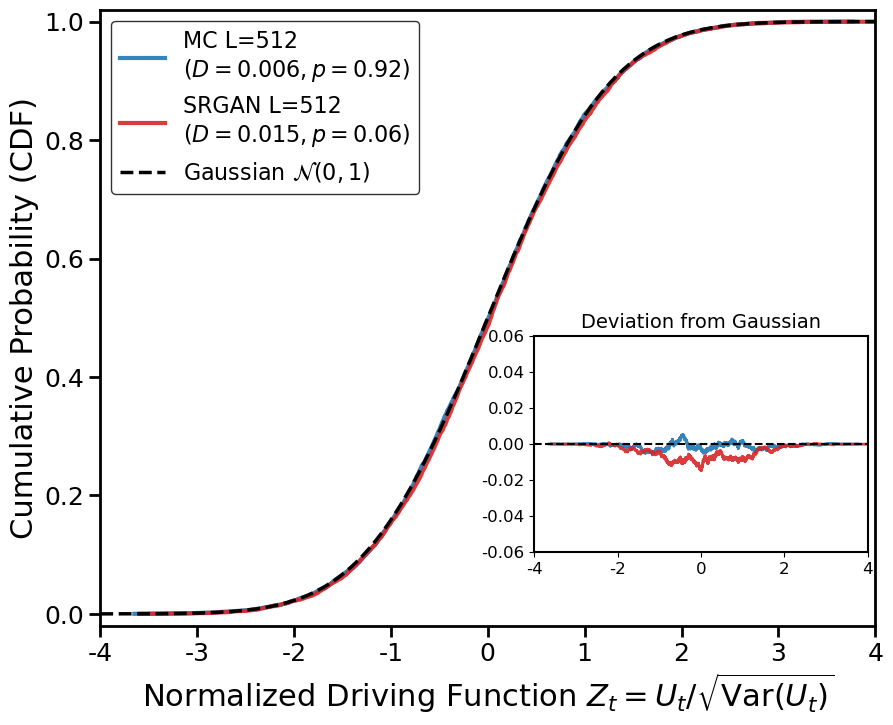

In [ ]:
import numpy as np
import h5py
import os
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'DejaVu Sans'

def check_fixed_time_distribution_inset_pdf():
    TARGET_T = 1000.0
    
    mc_path = r"D:\Code\final_srgan\interface\mc_interface\interface_processing\512x512\ising_512x512_10000_driven_results.h5"
    srgan_path = r"D:\Code\final_srgan\interface\srgan_interface\srgan_output_512_interface_processing\srgan_output_ising_512x512_10000_driven_results.h5"
    files = {
        'MC L=512': mc_path,
        'SRGAN L=512': srgan_path
    }

    
    def extract_U_at_T(filepath, label):
        if not os.path.exists(filepath):
            print(f"[Error] File not found: {filepath}")
            return None
            
        print(f"\n>>> Extracting U(t={TARGET_T}) for {label} ...")
        
        u_values_at_T = []
        
        with h5py.File(filepath, 'r') as hf:
            key_t = 't' if 't' in hf else 'delta_t'
            keys = sorted(hf[key_t].keys(), key=lambda x: int(x.split('_')[1]))
            keys = keys[:8000]
            
            for k in tqdm(keys, desc="  Searching", leave=False):
                t_series = hf[key_t][k][:]
                u_series = hf['u'][k][:]
                
                
                idx_end = np.searchsorted(t_series, TARGET_T)
                if idx_end >= len(t_series): idx_end = len(t_series) - 1
                elif idx_end > 0:
                    if abs(t_series[idx_end-1] - TARGET_T) < abs(t_series[idx_end] - TARGET_T):
                        idx_end = idx_end - 1
                
                u_final = u_series[idx_end]
                t_final = t_series[idx_end]
                
                if abs(t_final - TARGET_T) < 50.0:
                    u_values_at_T.append(u_final)
        
        return np.array(u_values_at_T)

    
    results = {}
    for lbl, p in files.items():
        res = extract_U_at_T(p, lbl)
        if res is not None and len(res) > 100:
            results[lbl] = res
            
    if not results: return

   
    fig, ax_main = plt.subplots(figsize=(10, 8))
    FONT_L = 22     
    FONT_T = 18     
    FONT_LEG = 16   
    LW = 3.0        
    colors = {'MC L=512': 'tab:blue', 'SRGAN L=512': 'tab:red'}
    ax_inset = ax_main.inset_axes([0.56, 0.12, 0.43, 0.35])
    
    print("\n" + "="*80)
    print(f"{'K-S TEST (Fixed t={int(TARGET_T)})':^80}")
    print("="*80)
    print(f"{'Label':<15} | {'Kappa':<8} | {'KS Dist (D)':<12} | {'P-value':<10}")
    print("-" * 80)

    for label, U_data in results.items():
        
        var_U = np.var(U_data)
        kappa_eff = var_U / TARGET_T
        Z = U_data / np.sqrt(var_U) 
        ks_stat, p_val = stats.kstest(Z, 'norm')
        
        print(f"{label:<15} | {kappa_eff:.4f}   | {ks_stat:.6f}     | {p_val:.2e}")
        
       
        sorted_z = np.sort(Z)
        n = len(sorted_z)
        y_emp = np.arange(1, n+1) / n
        y_th = stats.norm.cdf(sorted_z)
        diff = y_emp - y_th
        
        c = colors.get(label, 'black')
        stats_label = f"{label}\n($D={ks_stat:.3f}, p={p_val:.2f}$)"
        ax_main.plot(sorted_z, y_emp, color=c, lw=LW, alpha=0.9, label=stats_label)
        ax_inset.plot(sorted_z, diff, color=c, lw=2.0, alpha=0.9)



    x_th = np.linspace(-4, 4, 1000)
    ax_main.plot(x_th, stats.norm.cdf(x_th), 'k--', lw=2.5, label='Gaussian $\mathcal{N}(0,1)$', zorder=10)
    ax_main.set_xlabel(r"Normalized Driving Function $Z_t = U_t / \sqrt{\text{Var}(U_t)}$", fontsize=FONT_L)
    ax_main.set_ylabel("Cumulative Probability (CDF)", fontsize=FONT_L)
    ax_main.legend(fontsize=FONT_LEG, loc='upper left', frameon=True, edgecolor='black')
    ax_main.set_xlim(-4, 4)
    ax_main.set_ylim(-0.02, 1.02)
    ax_main.grid(False)
    ax_main.tick_params(axis='both', which='major', labelsize=FONT_T, length=8, width=2)
    
    for spine in ax_main.spines.values():
        spine.set_linewidth(2.0)

    ax_inset.axhline(0, color='k', ls='--', lw=1.5)
    ax_inset.set_title("Deviation from Gaussian", fontsize=14)
    ax_inset.tick_params(axis='both', which='major', labelsize=12)
    ax_inset.set_xlim(-4, 4) 
    ax_inset.set_ylim(-0.06, 0.06) 
    ax_inset.grid(False)
    
    for spine in ax_inset.spines.values():
        spine.set_linewidth(1.5)
    plt.show()

if __name__ == "__main__":
    check_fixed_time_distribution_inset_pdf()

Fractal Dimension

In [ ]:
import numpy as np
import h5py
import os
import warnings

# 忽略警告
warnings.filterwarnings("ignore")

def calculate_and_save_fractal_data():
    # ================= 配置区 =================
    SAMPLE_LIMIT = 10000  # 样本数限制

    # 路径配置
    mc_base_dir = r"mc_interface"
    srgan_base_dir = r"srgan_interface"

    # MC 数据源
    mc_configs = {
        64: "ising_64x64_10000_driven_results.h5",
        128: "ising_128x128_10000_driven_results.h5",
        256: "ising_256x256_10000_driven_results.h5",
        512: "ising_512x512_10000_driven_results.h5",
        1024: "ising_1024x1024_20000_driven_results.h5"
    }
    
    # SRGAN 数据源
    srgan_configs = {
        256: r"srgan_output_ising_256x256_10000_driven_results.h5",
        512: r"srgan_output_ising_512x512_10000_driven_results.h5",
        1024: r"srgan_output_ising_1024x1024_10000_driven_results.h5",
        2048: r"srgan_output_ising_2048x2048_10000_driven_results.h5"
    }

    # 结果容器
    final_results = {'MC': {'L': [], 'S': [], 'Err': []}, 
                     'SRGAN': {'L': [], 'S': [], 'Err': []}}

    # --- 核心处理函数 (串行) ---
    def process_category(configs, category_name, base_dir):
        print(f"== processing {category_name} ==")
        
        for L, subpath in configs.items():
            filepath = os.path.join(base_dir, subpath)
            
            if not os.path.exists(filepath):
                print(f"  v: {filepath}")
                continue
            
            try:
                print(f"  Loading L={L} ... ", end="", flush=True)
                with h5py.File(filepath, 'r') as hf:
                    # 获取前 SAMPLE_LIMIT 个样本
                    keys = list(hf['t'].keys())[:SAMPLE_LIMIT]
                    if not keys:
                        print("data doesn't exist")
                        continue
                    
                    lengths = []
                    for k in keys:
                        # shape[0] 即为界面长度 S (步数)
                        n_steps = hf['t'][k].shape[0]
                        lengths.append(n_steps)
                    
                    # 计算统计量
                    avg_len = np.mean(lengths)
                    sem = np.std(lengths) / np.sqrt(len(lengths))
                    
                    # 存入字典
                    final_results[category_name]['L'].append(L)
                    final_results[category_name]['S'].append(avg_len)
                    final_results[category_name]['Err'].append(sem)
                    
                    print(f"完成! <S>={avg_len:.1f}")
                    
            except Exception as e:
                print(f"出错: {e}")

    # 执行处理
    process_category(mc_configs, 'MC', mc_base_dir)
    process_category(srgan_configs, 'SRGAN', srgan_base_dir)

    # --- 排序与保存 ---
    for cat in ['MC', 'SRGAN']:
        # 转为 numpy array 并按 L 排序
        L_arr = np.array(final_results[cat]['L'])
        S_arr = np.array(final_results[cat]['S'])
        E_arr = np.array(final_results[cat]['Err'])
        
        sort_idx = np.argsort(L_arr)
        
        final_results[cat]['L'] = L_arr[sort_idx]
        final_results[cat]['S'] = S_arr[sort_idx]
        final_results[cat]['Err'] = E_arr[sort_idx]

    save_name = 'fractal_data.npy'
    np.save(save_name, final_results)

if __name__ == "__main__":
    calculate_and_save_fractal_data()

Loading fractal_data.npy
Method     | Size (L)   | Avg Length (S)  | Error (Err)
-------------------------------------------------------
MC         | 64.00      | 263.8302        | 0.7036    
MC         | 128.00     | 678.2716        | 1.8398    
MC         | 256.00     | 1773.4304       | 4.7641    
MC         | 512.00     | 4889.6672       | 13.9903   
MC         | 1024.00    | 11930.5310      | 32.2412   
SRGAN      | 256.00     | 1836.2308       | 4.9669    
SRGAN      | 512.00     | 4735.5480       | 12.9799   
SRGAN      | 1024.00    | 12390.3874      | 33.4621   
SRGAN      | 2048.00    | 34231.2076      | 98.1407   


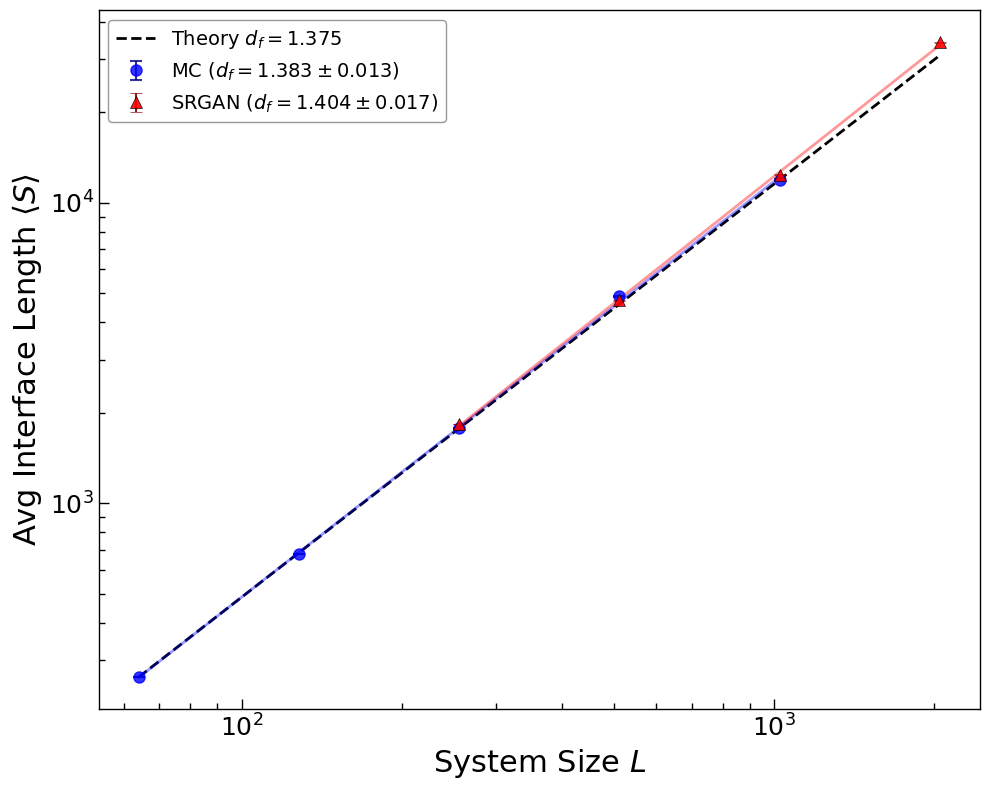

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams['axes.linewidth'] = 1.0 
plt.rcParams['xtick.major.width'] = 1.0 
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.direction'] = 'in' 
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.family'] = 'DejaVu Sans'

def power_law(L, C, df):
    return C * np.power(L, df)

def plot_fractal_dimension_refined():
    filename = 'fractal_data.npy'
    try:
        data = np.load(filename, allow_pickle=True).item()
        data_mc = data['MC']
        data_sr = data['SRGAN']
        print(f"Loading {filename}")
    except FileNotFoundError:
        print(f"file doesn't exist")
        return
    
    print(f"{'Method':<10} | {'Size (L)':<10} | {'Avg Length (S)':<15} | {'Error (Err)':<10}")
    print("-" * 55)

    for l, s, err in zip(data_mc['L'], data_mc['S'], data_mc['Err']):
        print(f"{'MC':<10} | {l:<10.2f} | {s:<15.4f} | {err:<10.4f}")

    for l, s, err in zip(data_sr['L'], data_sr['S'], data_sr['Err']):
        print(f"{'SRGAN':<10} | {l:<10.2f} | {s:<15.4f} | {err:<10.4f}")

    fig, ax = plt.subplots(figsize=(10, 8))
    
    FONT_LABEL = 22; FONT_TICK = 18; FONT_LEGEND = 14
    MARKER_SIZE = 8; LINE_WIDTH = 2.0

    # (df = 1.375) 
    if len(data_mc['L']) > 0:
        L_theo = np.logspace(np.log10(min(data_mc['L'])), np.log10(max(data_sr['L'])), 100)
        C_theo = data_mc['S'][0] / (data_mc['L'][0]**1.375)
        ax.plot(L_theo, power_law(L_theo, C_theo, 1.375), 'k--', 
                linewidth=2, label=r'Theory $d_f=1.375$', zorder=1)

    #  MC 
    if len(data_mc['L']) > 1:
        popt, pcov = curve_fit(power_law, data_mc['L'], data_mc['S'], 
                               p0=[C_theo, 1.375], sigma=data_mc['Err'])
        C_mc, df_mc = popt
        df_err_mc = np.sqrt(pcov[1, 1]) 
        
        ax.errorbar(data_mc['L'], data_mc['S'], yerr=data_mc['Err'], 
                    fmt='bo', markersize=MARKER_SIZE, alpha=0.8,
                    ecolor='navy', elinewidth=1.5, capsize=4, capthick=1.5,
                    label=rf'MC ($d_f={df_mc:.3f} \pm {df_err_mc:.3f}$)', zorder=4)
        
        ax.plot(data_mc['L'], power_law(data_mc['L'], C_mc, df_mc), 
                'b-', linewidth=LINE_WIDTH, alpha=0.4, zorder=2)

    # SRGAN 
    if len(data_sr['L']) > 1:
        popt, pcov = curve_fit(power_law, data_sr['L'], data_sr['S'], 
                               p0=[C_theo, 1.375], sigma=data_sr['Err'])
        C_sr, df_sr = popt
        df_err_sr = np.sqrt(pcov[1, 1])
        
        ax.errorbar(data_sr['L'], data_sr['S'], yerr=data_sr['Err'], 
                    fmt='r^', markersize=MARKER_SIZE+1, alpha=0.9,
                    markeredgecolor='k', markeredgewidth=0.5,
                    ecolor='darkred', elinewidth=1.5, capsize=4, capthick=1.5,
                    label=rf'SRGAN ($d_f={df_sr:.3f} \pm {df_err_sr:.3f}$)', zorder=5)
        
        ax.plot(data_sr['L'], power_law(data_sr['L'], C_sr, df_sr), 
                'r-', linewidth=LINE_WIDTH, alpha=0.4, zorder=3)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'System Size $L$', fontsize=FONT_LABEL)
    ax.set_ylabel(r'Avg Interface Length $\langle S \rangle$', fontsize=FONT_LABEL)
    ax.tick_params(axis='both', which='major', labelsize=FONT_TICK, length=7, width=1)
    ax.tick_params(axis='both', which='minor', length=4, width=1)
    ax.legend(fontsize=FONT_LEGEND, frameon=True, edgecolor='gray', loc='upper left')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_fractal_dimension_refined()

drive function comparison

In [ ]:
import numpy as np
import h5py
import os
import warnings
import time

warnings.filterwarnings("ignore")

#discard the part of interface near the top boundary
MIN_ALIVE_THRESHOLD = 9950 

NUM_POINTS = 2000 
SAMPLE_LIMIT = 10000 

def process_single_file_strict_serial(label, filepath):
    if not os.path.exists(filepath):
        print(f" file doesn't exist: {filepath}")
        return None

    try:
        with h5py.File(filepath, 'r') as hf:
            keys_t = set(hf['t'].keys())
            keys_u = set(hf['u'].keys())
            keys = list(keys_t & keys_u)
            if not keys: return None
            keys = keys[:SAMPLE_LIMIT]
            n_samples = len(keys)

            local_max_t = 0
            for k in keys:
                t_last = hf['t'][k][-1]
                if t_last > local_max_t: local_max_t = t_last
            
            t_targets = np.logspace(np.log10(10), np.log10(local_max_t), NUM_POINTS)
            
            aligned_matrix = np.full((n_samples, NUM_POINTS), np.nan)
            
            print(f"  processing{label} ({n_samples})... ", end='', flush=True)
            
            for i, k in enumerate(keys):
                t_raw = hf['t'][k][:]
                u_raw = hf['u'][k][:]
                
                if t_raw[-1] < 10: continue

                indices = np.searchsorted(t_raw, t_targets, side='left')
                indices = np.clip(indices, 0, len(t_raw) - 1)
                
                left_indices = np.maximum(indices - 1, 0)
                dist_curr = np.abs(t_raw[indices] - t_targets)
                dist_left = np.abs(t_raw[left_indices] - t_targets)
                
                use_left = dist_left < dist_curr
                final_indices = np.where(use_left, left_indices, indices)
                u_selected = u_raw[final_indices]
                
                is_dead_mask = t_targets > t_raw[-1]
                u_selected[is_dead_mask] = np.nan
                
                aligned_matrix[i, :] = u_selected

            live_counts = np.sum(~np.isnan(aligned_matrix), axis=0)
            valid_mask = live_counts > MIN_ALIVE_THRESHOLD
            
            t_final = t_targets[valid_mask]
            
            variance = np.nanvar(aligned_matrix, axis=0)
            var_final = variance[valid_mask]
            
            return (t_final, var_final)

    except Exception as e:
        print(f"\n  [Error] {label}: {e}")
        return None

if __name__ == '__main__':
    mc_base_dir = r"D:\Code\final_srgan\interface\mc_interface\interface_processing"
    srgan_base_dir = r"D:\Code\final_srgan\interface\srgan_interface"
    
    tasks = []
    
    # 任务列表
    mc_configs = {
        64: "ising_64x64_10000_driven_results.h5",
        128: "ising_128x128_10000_driven_results.h5",
        256: "ising_256x256_10000_driven_results.h5",
        512: "ising_512x512_10000_driven_results.h5",
        1024: "ising_1024x1024_20000_driven_results.h5"
    }
    for L, sub in mc_configs.items():
        tasks.append((f"MC_{L}", os.path.join(mc_base_dir, sub)))

    srgan_configs = {
        256: r"srgan_output_ising_256x256_10000_driven_results.h5",
        512: r"srgan_output_ising_512x512_10000_driven_results.h5",
        1024: r"srgan_output_ising_1024x1024_10000_driven_results.h5",
        2048: r"srgan_output_ising_2048x2048_10000_driven_results.h5"
    }
    for L, sub in srgan_configs.items():
        tasks.append((f"SRGAN_{L}", os.path.join(srgan_base_dir, sub)))


    final_results = {'MC': {}, 'SRGAN': {}}
    
    for label, filepath in tasks:
        data = process_single_file_strict_serial(label, filepath)
        if data:
            cat, size = label.split('_')
            final_results[cat][int(size)] = data

    save_name = 'variance_strict_cut_data.npy'
    np.save(save_name, final_results)
    print(f"data saved {save_name}")

Loading variance_strict_cut_data.npy


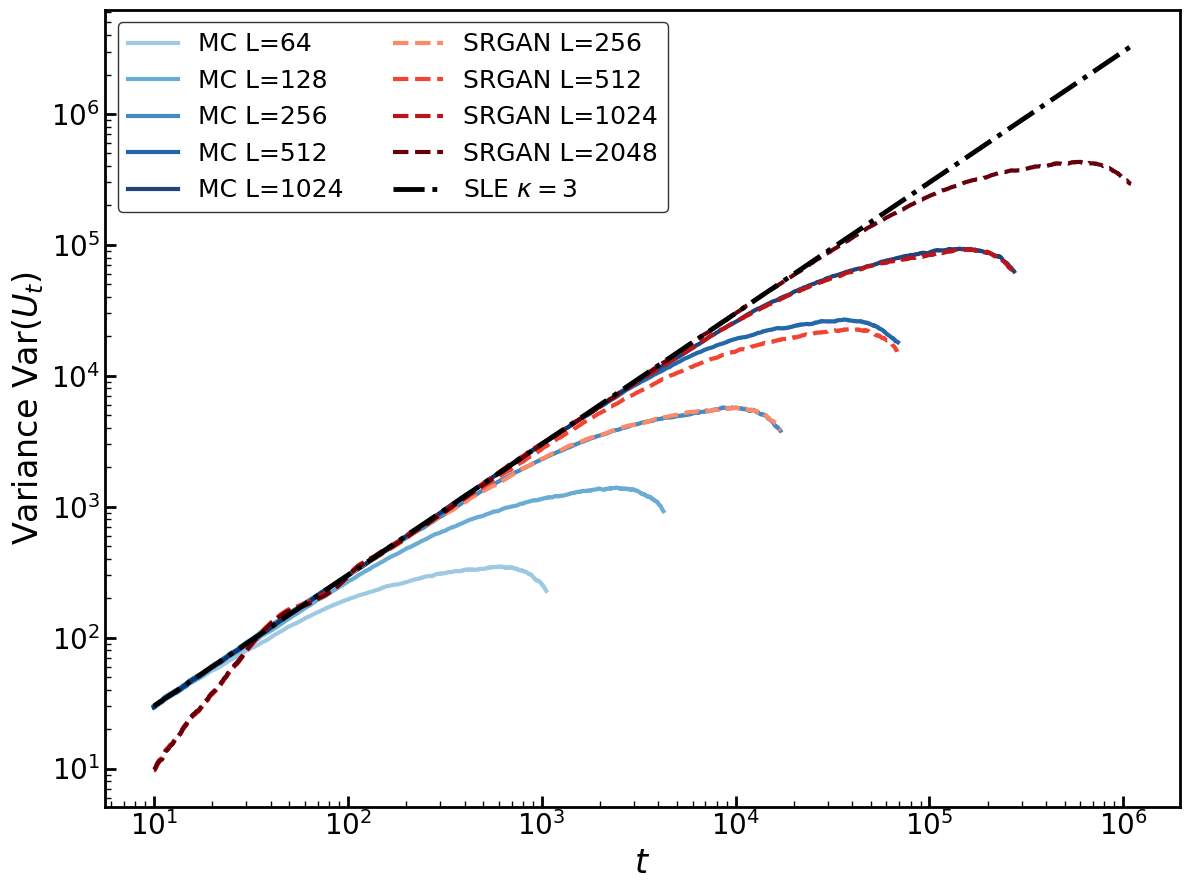

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 全局绘图设置
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'DejaVu Sans'

def plot_from_npy():
    # 1. 读取数据
    filename = 'variance_strict_cut_data.npy'
    try:
        data = np.load(filename, allow_pickle=True).item()
        mc_data = data.get('MC', {})
        srgan_data = data.get('SRGAN', {})
        print(f"Loading {filename}")
    except FileNotFoundError:
        print(f"{filename} doesn't exist")
        return

    # 2. 绘图配置
    plt.figure(figsize=(12, 9))
    
    FONT_L = 24    # 标签字体
    FONT_T = 20    # 刻度字体
    LW = 3.0       # 线宽
    
    # 3. 绘制 MC 数据
    mc_sizes = sorted(mc_data.keys())
    # 颜色映射 (从浅蓝到深蓝)
    colors_mc = cm.Blues(np.linspace(0.4, 1.0, len(mc_sizes)))
    
    for idx, L in enumerate(mc_sizes):
        if L not in mc_data: continue
        t, var = mc_data[L]
        plt.loglog(t, var, linestyle='-', color=colors_mc[idx], 
                   linewidth=LW, alpha=0.9, label=f'MC L={L}')

    # 4. 绘制 SRGAN 数据
    srgan_sizes = sorted(srgan_data.keys())
    # 颜色映射 (从浅红到深红)
    colors_sr = cm.Reds(np.linspace(0.4, 1.0, len(srgan_sizes)))
    
    for idx, L in enumerate(srgan_sizes):
        if L not in srgan_data: continue
        t, var = srgan_data[L]
        plt.loglog(t, var, linestyle='--', color=colors_sr[idx], 
                   linewidth=LW, alpha=1.0, label=f'SRGAN L={L}')

    max_t_vals = []
    if mc_data: max_t_vals.append(max(np.max(v[0]) for v in mc_data.values()))
    if srgan_data: max_t_vals.append(max(np.max(v[0]) for v in srgan_data.values()))
    
    if max_t_vals:
        global_max_t = max(max_t_vals)
        t_ref = np.logspace(1, np.log10(global_max_t), 100)
        plt.loglog(t_ref, 3.0 * t_ref, 'k-.', linewidth=3.5, 
                   zorder=10, label=r'SLE $\kappa=3$')

    plt.xlabel(r'$t$', fontsize=FONT_L)
    plt.ylabel(r'Variance $\text{Var}(U_t)$', fontsize=FONT_L)
    plt.tick_params(axis='both', which='major', labelsize=FONT_T, length=8, width=2)
    plt.tick_params(axis='both', which='minor', labelsize=FONT_T*0.8, length=4, width=1)
    plt.legend(fontsize=18, ncol=2, frameon=True, edgecolor='black', loc='upper left')
    plt.grid(False)
    
    for spine in plt.gca().spines.values():
        spine.set_linewidth(2.0)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_from_npy()

Left Passage Probability (Christoffel-Schwarz Mapping)

In [ ]:
import numpy as np
import h5py
import os
from scipy.special import ellipj, ellipk
from scipy.optimize import fsolve

def get_cs_params(h=1.0):
    def objective(m_val):
        return ellipk(1 - m_val) / ellipk(m_val) - 2 * h
    m = fsolve(objective, 0.17157)[0]
    return m, ellipk(m)

def apply_cs_square_map(z_curve, L, m, K):
    z_working = z_curve + (L/2 - z_curve[0].real)
    u = (np.clip(z_working.real, 1e-5, L-1e-5) * 2 * K / L) - K
    v = (np.clip(z_working.imag, 1e-5, L-1e-5) * 2 * K / L)
    m_p = 1.0 - m
    sn_u, cn_u, dn_u, _ = ellipj(u, m)
    sn_v, cn_v, dn_v, _ = ellipj(v, m_p)
    denom = 1.0 - (sn_u**2 * sn_v**2)
    w = (sn_u * dn_v + 1j * cn_u * dn_u * sn_v * cn_v) / denom
    return w - w[0]

def save_lpp_data_final(target_R=0.30):
    mc_dir = r"mc_interface"
    srgan_dir = r"srgan_interface"
    m_sq, K_sq = get_cs_params(1.0)
    
    file_configs = {
        'MC': {
            64: "ising_64_10000_Interface_Complex_coords.h5",
            128: "ising_128_10000_Interface_Complex_coords.h5",
            256: "ising_256_10000_Interface_Complex_coords.h5",
            512: "ising_512_10000_Interface_Complex_coords.h5",
            1024: "ising_1024_10000_Interface_Complex_coords.h5"
        },
        'SRGAN': {
            256: "srgan_output_ising_256_10000_Interface_Complex_coords.h5",
            512: "srgan_output_ising_512_10000_Interface_Complex_coords.h5",
            1024: "srgan_output_ising_1024_10000_Interface_Complex_coords.h5",
            2048: "srgan_output_ising_2048_10000_Interface_Complex_coords.h5"
        }
    }

    final_data = {'MC': {}, 'SRGAN': {}}
    thetas = np.linspace(0.1, np.pi - 0.1, 35) 

    for cat, sizes in file_configs.items():
        base_dir = mc_dir if cat == 'MC' else srgan_dir
        for L, fname in sizes.items():
            current_R = target_R 

            path = os.path.join(base_dir, fname)
            if not os.path.exists(path): continue
            
            angles = []
            skipped = 0
            with h5py.File(path, 'r') as hf:
                keys = list(hf.keys())
                if cat == 'MC' and L == 1024:
                    keys = keys[:10000]
                    
                for k in keys:
                    data = hf[k][:]
                    z = data if data.dtype.kind == 'c' \
                        else data[:,0] + 1j*data[:,1]
                    
                    w = apply_cs_square_map(z, L, m_sq, K_sq)
                    dists = np.abs(w)
                    cross = np.where(dists > current_R)[0]
                    
                    if len(cross) == 0:
                        skipped += 1
                        continue
                        
                    w_cross = w[cross[0]]
                    
                    if w_cross.imag < -1e-6:
                        skipped += 1
                        continue
                    else:
                        w_cross = w_cross.real + 1j * max(w_cross.imag, 0.0)
                        ang = np.clip(np.angle(w_cross), 0, np.pi)
                        angles.append(ang)
            
            angles = np.array(angles)
            N_effective = len(angles)
            if skipped > 0:
                print(f"  Warning: {skipped} samples skipped for L={L}")    
                
                 
            
            if N_effective > 0:
                p_vals = np.array([np.mean(angles > t) for t in thetas])
                
                final_data[cat][L] = {
                    't': thetas,
                    'p': p_vals,
                    'N': N_effective 
                }
                print(f"DONE: {cat} L={L} | Effective N={N_effective} | R={current_R}")

    np.save('lpp_cs_map.npy', final_data)

if __name__ == "__main__":
    save_lpp_data_final(target_R=0.30)

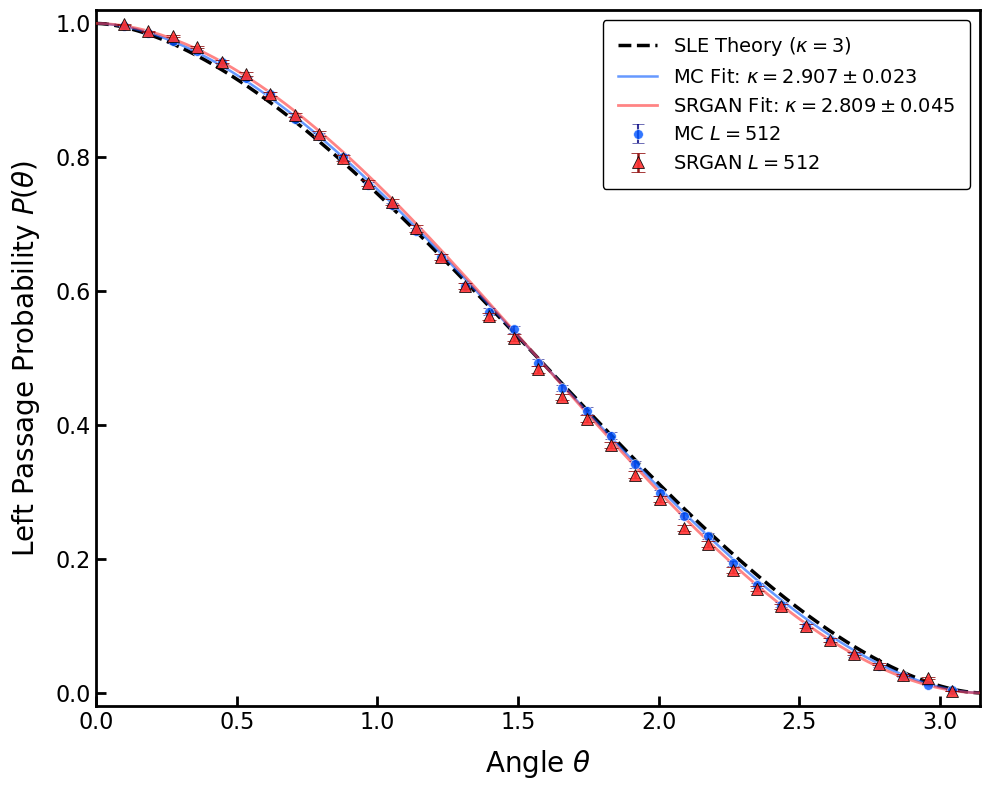

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import hyp2f1, gamma

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'DejaVu Sans'

def schramm_lpp_model(theta, kappa):
    epsilon = 1e-6
    theta = np.clip(theta, epsilon, np.pi - epsilon)
    cot_theta = 1.0 / np.tan(theta)
    k = np.abs(kappa)
    term1 = gamma(4.0/k) / (np.sqrt(np.pi) * gamma(4.0/k - 0.5))
    hypergeom = hyp2f1(4.0/k, 0.5, 1.5, -(cot_theta**2))
    return 0.5 + term1 * cot_theta * hypergeom

def plot_lpp_professional():
    try:
        data = np.load('lpp_cs_map.npy', allow_pickle=True).item()
    except Exception as e:
        print(f"Data not found: {e}")
        return

    fig, ax = plt.subplots(figsize=(10, 8))
    
    C_MC, C_MC_ERR = '#0055ff', '#000080'  
    C_SR, C_SR_ERR = '#ff3333', '#8b0000' 
    
    ts_plot = np.linspace(0, np.pi, 300)

    ax.plot(ts_plot, schramm_lpp_model(ts_plot, 3.0), color='black', 
            linewidth=2.5, linestyle='--', label=r'SLE Theory ($\kappa=3$)', zorder=1)

    target_L = 512

    if 'MC' in data and target_L in data['MC']:
        res = data['MC'][target_L]
        
        p_left = res['p']
        
        mask = (res['t'] > np.pi * 0.25) & (res['t'] < np.pi * 0.75)
        
        popt, pcov = curve_fit(schramm_lpp_model, res['t'][mask], p_left[mask], p0=[3.0])
        k_mc, k_err_mc = popt[0], np.sqrt(pcov[0,0])
        
        sigma_p = np.sqrt(p_left * (1 - p_left) / res['N'])
        
        ax.errorbar(res['t'], p_left, yerr=sigma_p, fmt='o', color=C_MC,
                    markersize=7, alpha=0.8, markeredgecolor='white', markeredgewidth=0.5,
                    ecolor=C_MC_ERR, elinewidth=1.5, capsize=4, capthick=1.5,
                    label=f'MC $L={target_L}$', zorder=4)
        
        ax.plot(ts_plot, schramm_lpp_model(ts_plot, k_mc), color=C_MC, linestyle='-',
                linewidth=1.8, alpha=0.6, label=rf'MC Fit: $\kappa={k_mc:.3f} \pm {k_err_mc:.3f}$', zorder=2)

    if 'SRGAN' in data and target_L in data['SRGAN']:
        res = data['SRGAN'][target_L]
        
        p_left = res['p']
        
        mask = (res['t'] > np.pi * 0.25) & (res['t'] < np.pi * 0.75)
        
        popt, pcov = curve_fit(schramm_lpp_model, res['t'][mask], p_left[mask], p0=[3.0])
        k_sr, k_err_sr = popt[0], np.sqrt(pcov[0,0])
        
        sigma_p = np.sqrt(p_left * (1 - p_left) / res['N'])
        
        ax.errorbar(res['t'], p_left, yerr=sigma_p, fmt='^', color=C_SR,
                    markersize=8, alpha=0.9, markeredgecolor='black', markeredgewidth=0.6,
                    ecolor=C_SR_ERR, elinewidth=1.8, capsize=5, capthick=1.8,
                    label=f'SRGAN $L={target_L}$', zorder=5)
        
        ax.plot(ts_plot, schramm_lpp_model(ts_plot, k_sr), color=C_SR, linestyle='-',
                linewidth=2.0, alpha=0.6, label=rf'SRGAN Fit: $\kappa={k_sr:.3f} \pm {k_err_sr:.3f}$', zorder=3)

    ax.set_xlabel(r'Angle $\theta$', fontsize=20, labelpad=10)
    ax.set_ylabel(r'Left Passage Probability $P(\theta)$', fontsize=20, labelpad=10)
    ax.set_xlim(0, np.pi)
    ax.set_ylim(-0.02, 1.02)
    ax.tick_params(labelsize=16, width=2, length=7)
    ax.tick_params(which='minor', width=1.5, length=4)
    
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    ax.legend(fontsize=14, loc='upper right', frameon=True, 
              edgecolor='black', framealpha=1, borderpad=0.8)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_lpp_professional()

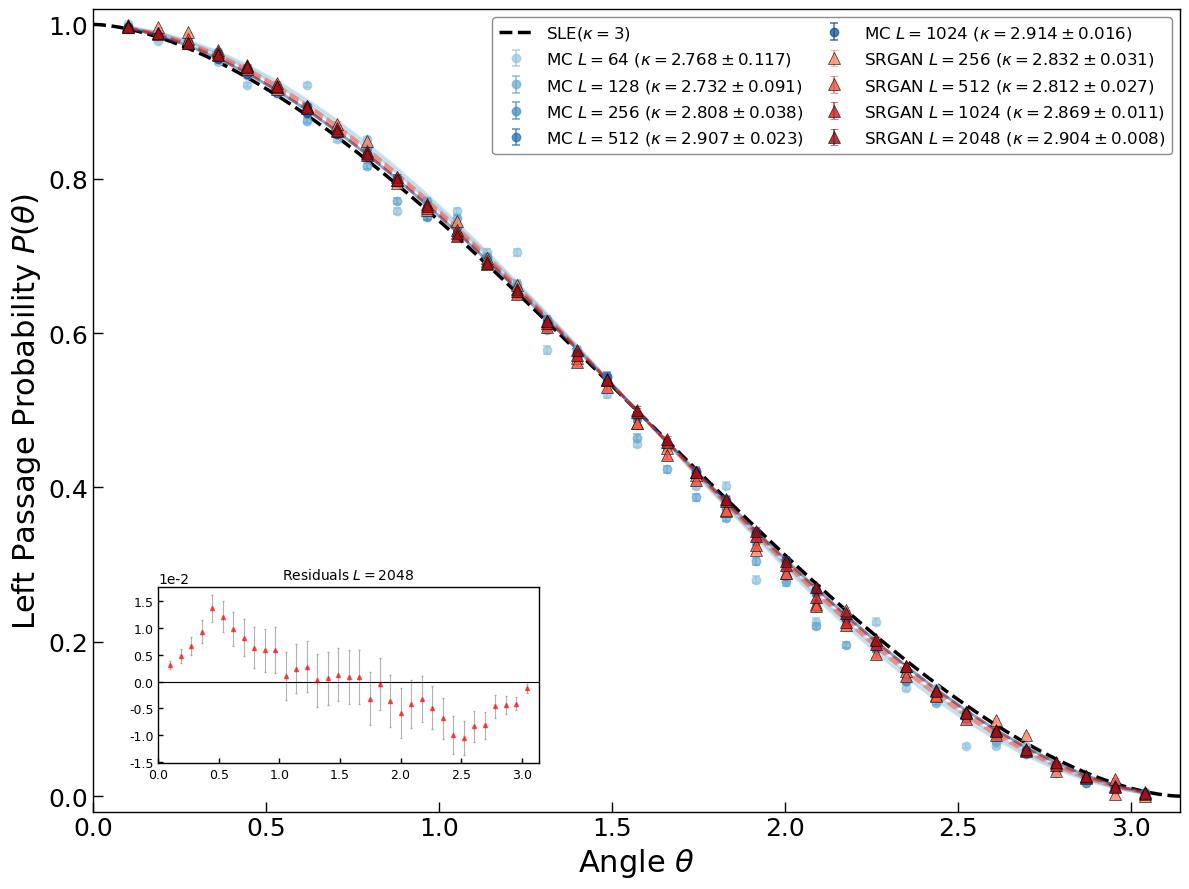

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.special import hyp2f1, gamma
from scipy.optimize import curve_fit

plt.rcParams['axes.linewidth'] = 1.0   
plt.rcParams['xtick.major.width'] = 1.0 
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.direction'] = 'in'    
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.family'] = 'DejaVu Sans'

def schramm_lpp_model(theta, kappa):
    epsilon = 1e-6
    theta = np.clip(theta, epsilon, np.pi - epsilon)
    cot_theta = 1.0 / np.tan(theta)
    k = np.abs(kappa)
    term1 = gamma(4.0/k) / (np.sqrt(np.pi) * gamma(4.0/k - 0.5))
    hypergeom = hyp2f1(4.0/k, 0.5, 1.5, -(cot_theta**2))
    return 0.5 + term1 * cot_theta * hypergeom

def plot_lpp_publication_ready():
    try:
        data = np.load('lpp_cs_map.npy', allow_pickle=True).item()
        mc_data, srgan_data = data['MC'], data['SRGAN']
    except Exception as e: 
        print(f"fail to load: {e}")
        return

    fig, ax = plt.subplots(figsize=(12, 9))

    LABEL_SIZE = 22    
    TICK_SIZE = 18     
    LEGEND_SIZE = 12   
    LINE_W = 2.0   
    ERR_W = 1.2     
    
    #  theory
    x_theo = np.linspace(0, np.pi, 250)
    ax.plot(x_theo, schramm_lpp_model(x_theo, 3.0), 'k--', 
            linewidth=2.5, label=r'SLE($\kappa=3$)', zorder=1)

    # MC 
    mc_sizes = sorted(mc_data.keys())
    c_mc = cm.Blues(np.linspace(0.4, 0.9, len(mc_sizes)))
    for i, L in enumerate(mc_sizes):
        res = mc_data[L]
        
        p_left = res['p']
        
        mask = (res['t'] > np.pi * 0.25) & (res['t'] < np.pi * 0.75)
        popt, pcov = curve_fit(schramm_lpp_model, res['t'][mask], p_left[mask], p0=[3.0])
        k_fit, k_err = popt[0], np.sqrt(pcov[0,0])
        sigma_p = np.sqrt(p_left * (1 - p_left) / res['N'])
        
        ax.errorbar(res['t'], p_left, yerr=sigma_p, fmt='o', color=c_mc[i], 
                    markersize=6, alpha=0.7, ecolor=c_mc[i], elinewidth=ERR_W, 
                    capsize=3, capthick=ERR_W, 
                    label=rf"MC $L={L}$ ($\kappa={k_fit:.3f}\pm{k_err:.3f}$)")
        ax.plot(res['t'], schramm_lpp_model(res['t'], k_fit), '-', color=c_mc[i], linewidth=LINE_W, alpha=0.3)

    # SRGAN 
    srgan_sizes = sorted(srgan_data.keys())
    c_sr = cm.Reds(np.linspace(0.4, 0.9, len(srgan_sizes)))
    for i, L in enumerate(srgan_sizes):
        res = srgan_data[L]
        
        p_left = res['p']
        
        mask = (res['t'] > 0.1) & (res['t'] < np.pi - 0.1)
        popt, pcov = curve_fit(schramm_lpp_model, res['t'][mask], p_left[mask], p0=[3.0])
        k_fit, k_err = popt[0], np.sqrt(pcov[0,0])
        sigma_p = np.sqrt(p_left * (1 - p_left) / res['N'])
        
        ax.errorbar(res['t'], p_left, yerr=sigma_p, fmt='^', color=c_sr[i], 
                    markersize=8, alpha=0.8, markeredgecolor='k', markeredgewidth=0.5,
                    ecolor=c_sr[i], elinewidth=ERR_W, capsize=3, capthick=ERR_W,
                    label=rf"SRGAN $L={L}$ ($\kappa={k_fit:.3f}\pm{k_err:.3f}$)")
        ax.plot(res['t'], schramm_lpp_model(res['t'], k_fit), '--', color=c_sr[i], linewidth=LINE_W, alpha=0.4)

    ax.set_xlabel(r'Angle $\theta$', fontsize=LABEL_SIZE)
    ax.set_ylabel(r'Left Passage Probability $P(\theta)$', fontsize=LABEL_SIZE)
    ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE, length=7)
    
    ax.set_xlim(0, np.pi)
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=LEGEND_SIZE, loc='upper right', ncol=2, 
              frameon=True, edgecolor='gray', framealpha=0.9, columnspacing=0.8)

    if srgan_sizes:
        best_L = srgan_sizes[-1]
        best_res = srgan_data[best_L]
        
        p_left_best = best_res['p']
        
        ax_ins = ax.inset_axes([0.06, 0.06, 0.35, 0.22])
        p_theo = schramm_lpp_model(best_res['t'], 3.0)
        residuals = p_left_best - p_theo
        sigma = np.sqrt(p_theo * (1 - p_theo) / best_res['N'])
        
        ax_ins.errorbar(best_res['t'], residuals, yerr=sigma, fmt='^', color='r', 
                        ecolor='gray', elinewidth=0.8, capsize=1, markersize=3, alpha=0.6)
        
        ax_ins.axhline(0, color='k', linestyle='-', linewidth=0.8)
        ax_ins.set_title(rf"Residuals $L={best_L}$", fontsize=10)
        ax_ins.set_xlim(0, np.pi)
        ax_ins.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))
        ax_ins.tick_params(labelsize=9)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_lpp_publication_ready()